# 💼 Business Insights & Demographic Analysis
## Customer Churn Predictor

### Purpose
This notebook translates model predictions into actionable business insights. While the modeling notebook focuses on building and evaluating models, this notebook answeres the business question:

**"Who is churning, why are they churning, and what can we do about it?"**

### What This Notebook Covers:
1. Load processed data and model predictions
2. Churn analysis by tenure group
3. Churn analysis by senior citizen status
4. Churn analysis by contract type
5. High value vs low value customer analysis
6. Combined demograhic risk heatmap
7. Business recommendations

## 👥 Feature Importance by Customer Demographics

### Why analyze by demographics?
Global feature importance tells us what drives churn **on average** across all customers. But churn drivers can vary significantly across different customer segments:
* A feature important for **new customers** may be irrelevant for long-term customers
* **Senior citizens** may churn for different reasons than younger customers
* **High-value customers** may respond to different retention strategies than low value ones

By analyzing feature importance across segments, we can help business design **targeted retention strategies** for each group rather than a one-size-fits-all approach.

### Segments we analyze:
1. **Tenure Group** - New vs. Developing vs. Established vs. Loyal Customers
2. **Senior Citizens** vs Non-Senior Citizens
3. **Contract Type** - Month-to-Month vs Long-term
4. **Customer Value** - High value vs low value

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# Load processed data
df = pd.read_csv('../data/processed/telco_churn_processed.csv')

# Load best model — use XGBoost
with open('../models/xgboost.pkl', 'rb') as f:
    best_xgb = pickle.load(f)

# Recreate train/test split with same random state
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Generate predictions
y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

# Build analysis dataframe
test_df = X_test.copy()
test_df['Churn'] = y_test.values
test_df['Churn_Prob'] = y_prob_xgb

print(f'✅ Data loaded: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'✅ Model loaded: XGBoost')
print(f'✅ Test set ready: {test_df.shape[0]} customers')
print(f'Churn rate in test set: {test_df["Churn"].mean():.2%}')

✅ Data loaded: 7043 rows, 34 columns
✅ Model loaded: XGBoost
✅ Test set ready: 1409 customers
Churn rate in test set: 26.54%


### 1. Churn Rate by Tenure Group
Tenure is one of the strongest churn predictors. Here we break down churn rate across our engineered tenure groups to visualize how customer loyalty evolves over time.

**Business Insight:** Understanding at which tenure stage customers are most at risk allows the business to time retention interventions more effectively - for example, targeting customers approaching the 12-month mark before they decide to leave.

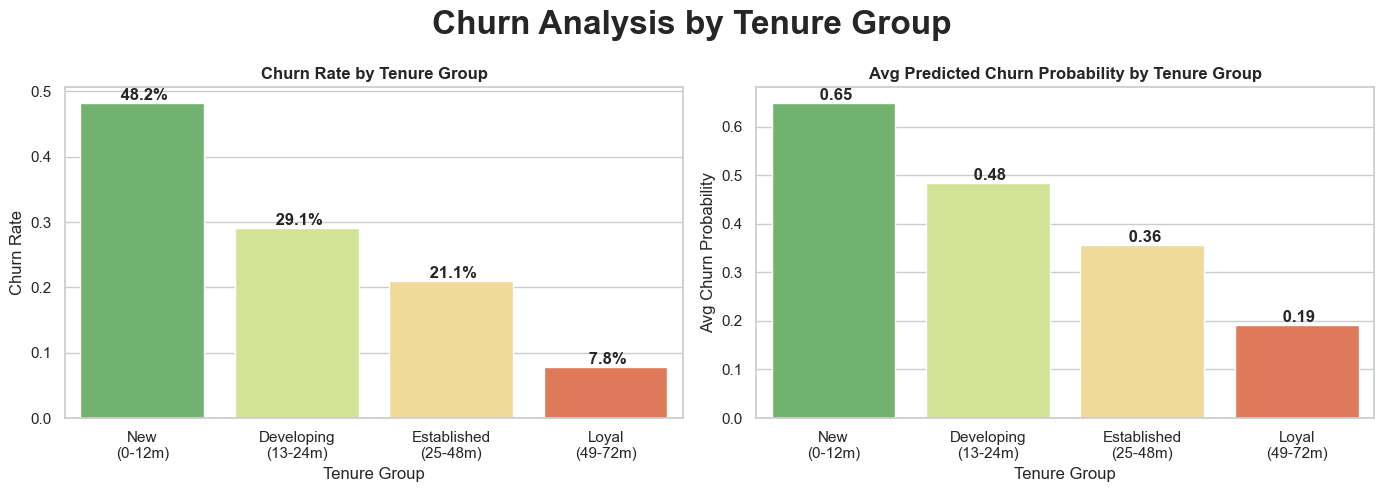


📊 Tenure Group Summary:
   tenure_group_label  Churn_Rate  Avg_Churn_Prob  Customer_Count
         New\n(0-12m)    0.482063        0.648254             446
 Developing\n(13-24m)    0.291262        0.483221             206
Established\n(25-48m)    0.210526        0.355630             304
      Loyal\n(49-72m)    0.077778        0.191074             450


In [4]:
test_df['tenure_group_label'] = pd.cut(test_df['tenure'],
                                       bins = [0, 12, 24, 48, 72],
                                       labels = ['New\n(0-12m)', 'Developing\n(13-24m)',
            'Established\n(25-48m)', 'Loyal\n(49-72m)']
)

tenure_churn = test_df.groupby('tenure_group_label', observed = True).agg(
    Churn_Rate = ('Churn', 'mean'),
    Avg_Churn_Prob = ('Churn_Prob', 'mean'),
    Customer_Count = ('Churn', 'count')
).reset_index()

fig, axes = plt.subplots(1,2, figsize = (14,5))

bars = sns.barplot(data = tenure_churn, x = 'tenure_group_label',
                   y = 'Churn_Rate', ax = axes[0], palette = 'RdYlGn_r')
axes[0].set_title('Churn Rate by Tenure Group', fontweight = 'bold')
axes[0].set_ylabel('Churn Rate')
axes[0].set_xlabel('Tenure Group')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height(): .1%}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha = 'center', va = 'bottom', fontweight = 'bold')

sns.barplot(data = tenure_churn, x = 'tenure_group_label',
            y = 'Avg_Churn_Prob', ax = axes[1], palette = 'RdYlGn_r')
axes[1].set_title('Avg Predicted Churn Probability by Tenure Group', fontweight = 'bold')
axes[1].set_ylabel('Avg Churn Probability')
axes[1].set_xlabel('Tenure Group')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height(): .2f}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha = 'center', va = 'bottom', fontweight = 'bold')

plt.suptitle('Churn Analysis by Tenure Group', fontsize = 24, fontweight = 'bold')
plt.tight_layout()
plt.savefig('../reports/figures/churn_by_tenure_group.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Tenure Group Summary:')
print(tenure_churn.to_string(index=False))

### 2. Churn Rate by Senior Citizen Status

Senior citizens may have different technology comfort levels, service needs, and price sensitivity compared to non-senior customers. Analyzing their churn patterns separately helps identify whether targeted support programs could improve retention in this segment.

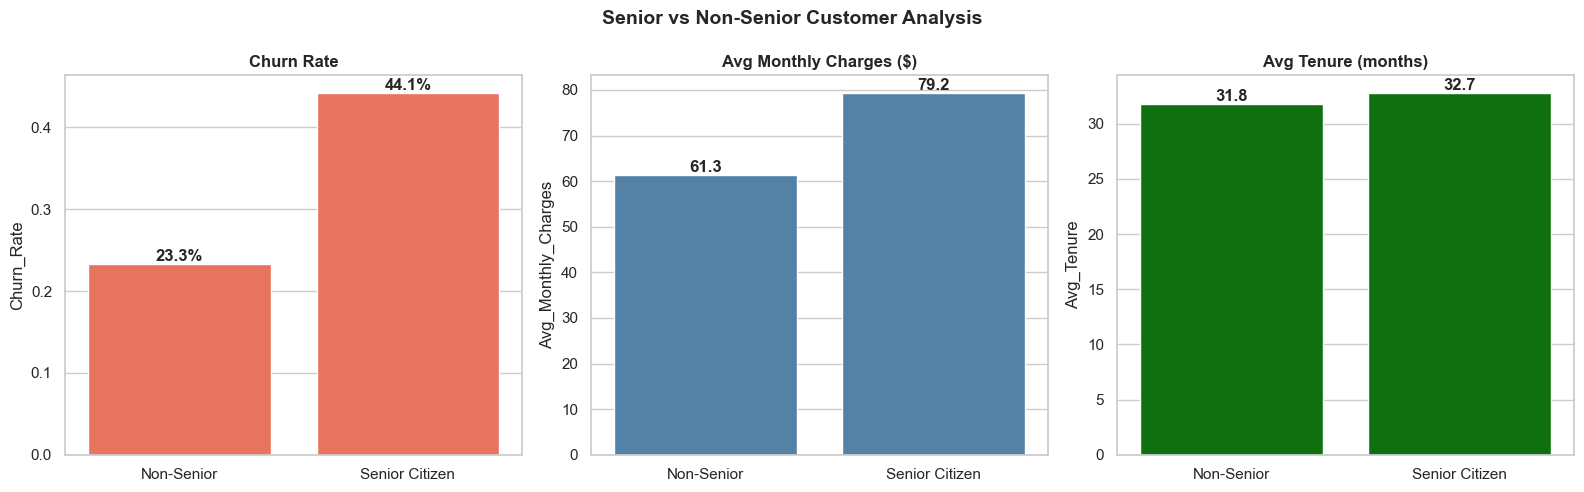


📊 Senior Citizen Summary:
 SeniorCitizen  Churn_Rate  Avg_Monthly_Charges  Avg_Tenure  Avg_Churn_Prob  Count
    Non-Senior    0.232519            61.257119   31.760741        0.382154   1187
Senior Citizen    0.441441            79.229730   32.743243        0.585053    222


In [5]:
senior_churn = test_df.groupby('SeniorCitizen').agg(
    Churn_Rate = ('Churn', 'mean'),
    Avg_Monthly_Charges = ('MonthlyCharges', 'mean'),
    Avg_Tenure = ('tenure', 'mean'),
    Avg_Churn_Prob = ('Churn_Prob', 'mean'),
    Count = ('Churn', 'count')
).reset_index()

senior_churn['SeniorCitizen'] = senior_churn['SeniorCitizen'].map(
    {0: 'Non-Senior', 1: 'Senior Citizen'}
)

fig, axes = plt.subplots(1,3, figsize = (16,5))

metrics = ['Churn_Rate', 'Avg_Monthly_Charges', 'Avg_Tenure']
titles = ['Churn Rate', 'Avg Monthly Charges ($)', 'Avg Tenure (months)']
colors = ['tomato', 'steelblue', 'green']

for i, (metric, title, color) in enumerate(zip(metrics, titles, colors)):
    sns.barplot(data=senior_churn, x='SeniorCitizen',
                y=metric, ax=axes[i], color=color)
    axes[i].set_title(title, fontweight='bold')
    axes[i].set_xlabel('')
    for p in axes[i].patches:
        val = p.get_height()
        label = f'{val:.1%}' if metric == 'Churn_Rate' else f'{val:.1f}'
        axes[i].annotate(label,
                         (p.get_x() + p.get_width() / 2, val),
                         ha='center', va='bottom', fontweight='bold')

plt.suptitle('Senior vs Non-Senior Customer Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/churn_by_senior.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Senior Citizen Summary:')
print(senior_churn.to_string(index=False))

### 3. Churn Rate by Contract Type

Contract type is consistently one of the strongest churn predictors across all of our models. Month-to-month customers have the lowest switching cost - they can leave at any time with no penalty.

**Business Insights:** Converting month-to-month customers to annual contracts through incentives (discounts, bundled services) is likely the single highest-impact retention strategy available.

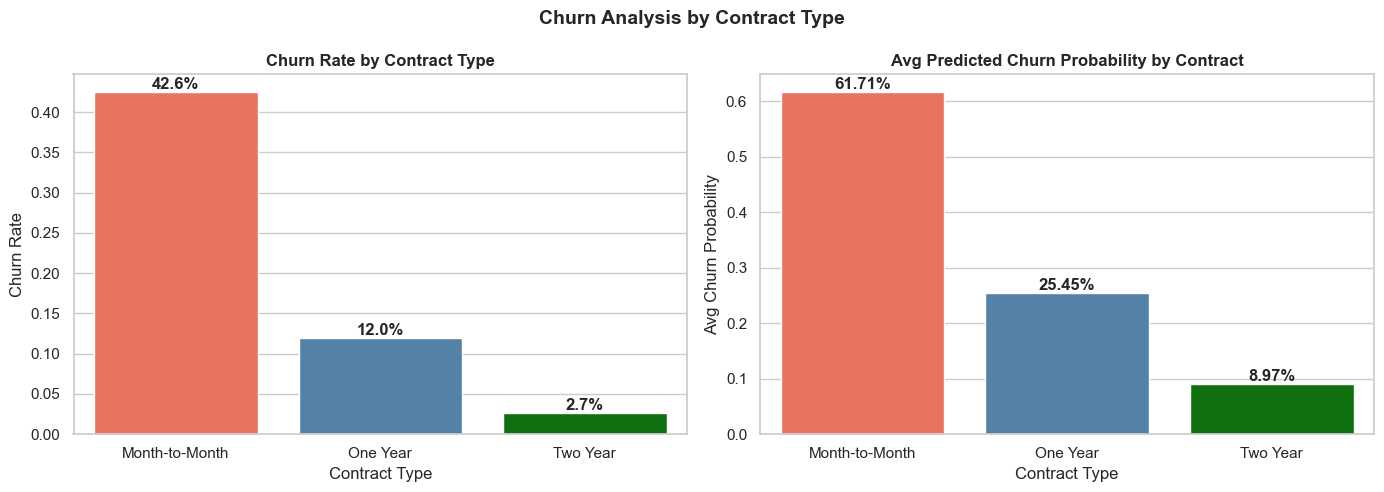


📊 Contract Type Summary:
 contract_type  Churn_Rate  Avg_Monthly_Charges  Avg_Tenure  Avg_Churn_Prob  Count
Month-to-Month    0.425614            66.014748   17.657180        0.617071    773
      One Year    0.120000            63.293167   40.486667        0.254491    300
      Two Year    0.026786            60.368601   57.065476        0.089747    336


In [7]:
def get_contract_type(row):
    if 'Contract_One year' in row.index and row['Contract_One year'] == 1:
        return 'One Year'
    elif 'Contract_Two year' in row.index and row['Contract_Two year'] == 1:
        return 'Two Year'
    else: 
        return 'Month-to-Month'

test_df['contract_type'] = test_df.apply(get_contract_type, axis = 1)

contract_churn = test_df.groupby('contract_type').agg(
    Churn_Rate = ('Churn', 'mean'),
    Avg_Monthly_Charges = ('MonthlyCharges', 'mean'),
    Avg_Tenure = ('tenure', 'mean'),
    Avg_Churn_Prob = ('Churn_Prob', 'mean'),
    Count = ('Churn', 'count')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize = (14,5))

sns.barplot(data=contract_churn, x='contract_type',
            y='Churn_Rate', ax=axes[0],
            palette=['tomato', 'steelblue', 'green'],
            order=['Month-to-Month', 'One Year', 'Two Year'])
axes[0].set_title('Churn Rate by Contract Type', fontweight = 'bold')
axes[0].set_ylabel('Churn Rate')
axes[0].set_xlabel('Contract Type')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1%}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

sns.barplot(data=contract_churn, x='contract_type',
            y='Avg_Churn_Prob', ax=axes[1],
            palette=['tomato', 'steelblue', 'green'],
            order=['Month-to-Month', 'One Year', 'Two Year'])
axes[1].set_title('Avg Predicted Churn Probability by Contract', fontweight = 'bold')
axes[1].set_ylabel('Avg Churn Probability')
axes[1].set_xlabel('Contract Type')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.2%}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')
    
plt.suptitle('Churn Analysis by Contract Type', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.savefig('../reports/figures/churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Contract Type Summary:')
print(contract_churn.to_string(index = False))

### 4. High Value vs Low Value Customer Analysis

High-value customers (above 75th percentile of monthly charges) represent disproportionate revenue. Losing one high-value customer has a much bigger financial impact than losing a low-value customer.

**Business Insight:** High-value churners should receive priority attention from the retention team - personalized outreach, premium support, and tailored offers rather than generic discounts.

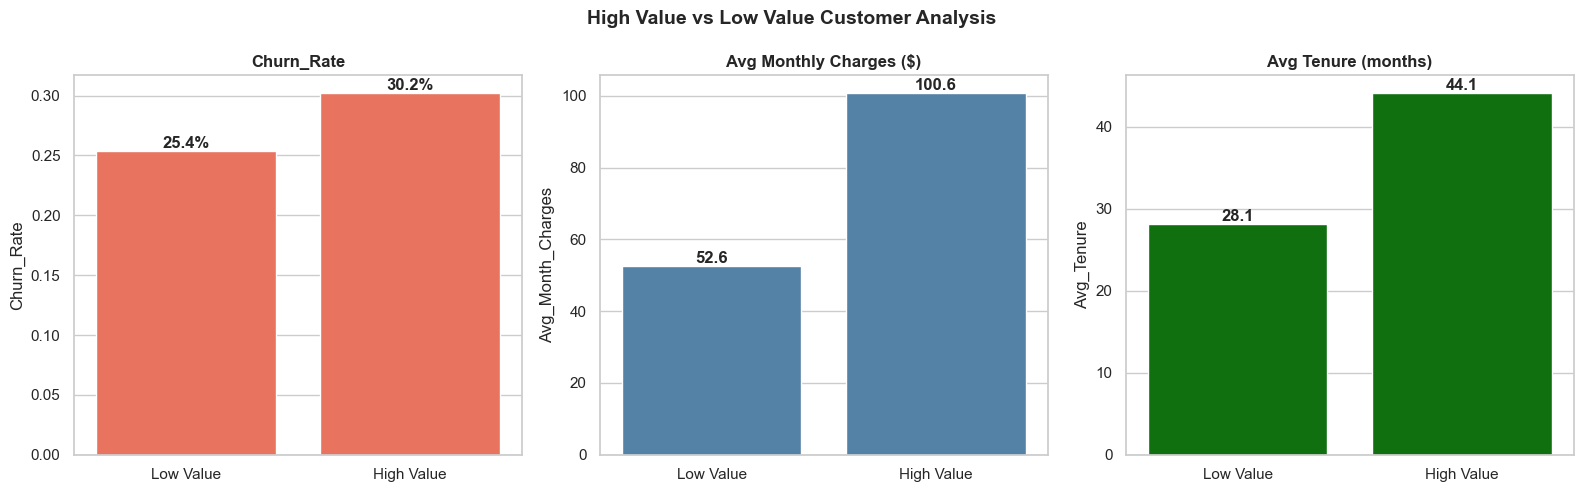


📊 Customer Value Summary:
is_high_value  Churn_Rate  Avg_Month_Charges  Avg_Tenure  Avg_Churn_Prob  Count
    Low Value    0.253968          52.555369   28.084034        0.385854   1071
   High Value    0.301775         100.634320   44.056213        0.503693    338


In [12]:
value_churn = test_df.groupby('is_high_value').agg(
    Churn_Rate = ('Churn', 'mean'),
    Avg_Month_Charges = ('MonthlyCharges', 'mean'),
    Avg_Tenure = ('tenure', 'mean'),
    Avg_Churn_Prob = ('Churn_Prob', 'mean'),
    Count = ('Churn', 'count')
).reset_index()

value_churn['is_high_value'] = value_churn['is_high_value'].map(
    {0: 'Low Value', 1: 'High Value'}
)

fig, axes = plt.subplots(1, 3, figsize = (16,5))

metrics = ['Churn_Rate', 'Avg_Month_Charges', 'Avg_Tenure']
titles = ['Churn_Rate', 'Avg Monthly Charges ($)', 'Avg Tenure (months)']
colors = ['tomato', 'steelblue', 'green']

for i, (metric, title, color) in enumerate(zip(metrics, titles, colors)):
    sns.barplot(data = value_churn, x = 'is_high_value',
                y = metric, ax = axes[i], color = color)
    axes[i].set_title(title, fontweight = 'bold')
    axes[i].set_xlabel('')
    for p in axes[i].patches:
        val = p.get_height()
        label = f'{val:.1%}' if metric == 'Churn_Rate' else f'{val:.1f}'
        axes[i].annotate(label, (p.get_x() + p.get_width() / 2, val), ha = 'center', va = 'bottom', fontweight = 'bold')

plt.suptitle('High Value vs Low Value Customer Analysis', fontsize = 14, fontweight = 'bold')
plt.tight_layout()

plt.savefig('../reports/figures/churn_by_value.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Customer Value Summary:')
print(value_churn.to_string(index=False))

In [11]:
print(value_churn.columns.tolist())
print(value_churn.head())

['is_high_value', 'Churn_Rate', 'Avg_Month_Charges', 'Avg_Tenure', 'Avg_Churn_Prob', 'Count']
  is_high_value  Churn_Rate  Avg_Month_Charges  Avg_Tenure  Avg_Churn_Prob  \
0     Low Value    0.253968          52.555369   28.084034        0.385854   
1    High Value    0.301775         100.634320   44.056213        0.503693   

   Count  
0   1071  
1    338  


### 5. Combined Demographic Risk Heatmap

The heatmap below combines multiple demograhic segments to identify **the highest risk customer profile** - the intersection of segments with the highest churn probability.

This directly answers the business question: **"Which type of customer should we prioritize for retention outreach?**

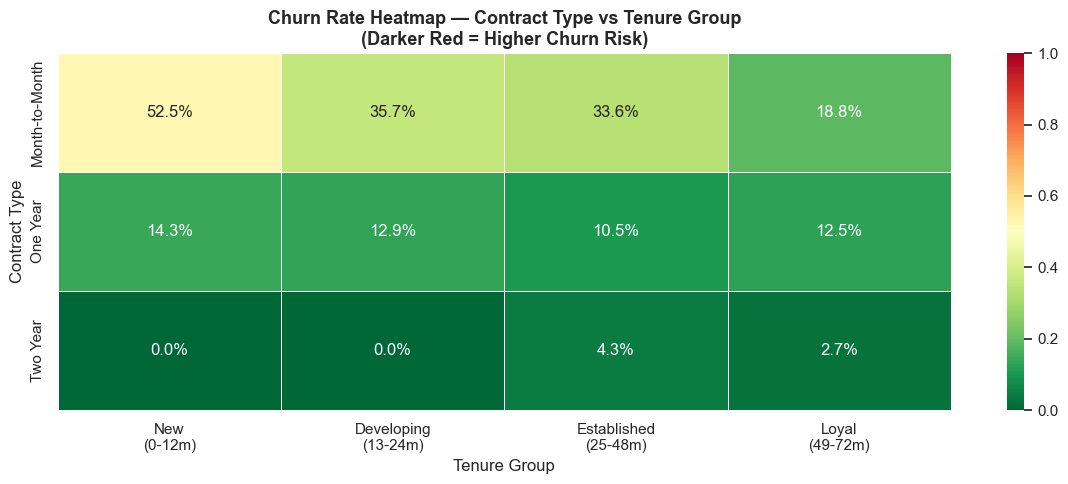

In [13]:
heatmap_df = test_df.groupby(['contract_type', 'tenure_group_label'], observed = True)['Churn'].mean().reset_index()

heatmap_pivot = heatmap_df.pivot(
    index = 'contract_type', 
    columns = 'tenure_group_label',
    values = 'Churn'
)

plt.figure(figsize = (12,5))
sns.heatmap(heatmap_pivot,
            annot = True,
            fmt = '.1%',
            cmap = 'RdYlGn_r',
            linewidths = 0.5, 
            vmin = 0,
            vmax = 1)

plt.title('Churn Rate Heatmap — Contract Type vs Tenure Group\n'
          '(Darker Red = Higher Churn Risk)',
          fontsize=13, fontweight='bold')
plt.xlabel('Tenure Group')
plt.ylabel('Contract Type')
plt.tight_layout()
plt.savefig('../reports/figures/churn_heatmap_demographics.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Final Business Insights Summary

In [14]:
print('=' * 60)
print('DEMOGRAPHIC ANALYSIS — KEY BUSINESS INSIGHTS')
print('=' * 60)

print('\n🔴 HIGHEST RISK SEGMENTS:')
print('1. New customers (0-12 months) on month-to-month contracts')
print('2. Senior citizens with high monthly charges')
print('3. High-value customers with no tech support')

print('\n💰 REVENUE IMPACT:')
high_val_churners = test_df[(test_df['is_high_value'] == 1) &
                             (test_df['Churn'] == 1)]
low_val_churners  = test_df[(test_df['is_high_value'] == 0) &
                             (test_df['Churn'] == 1)]
print(f'High-value churners: {len(high_val_churners)} customers')
print(f'Avg monthly charge:  ${high_val_churners["MonthlyCharges"].mean():.2f}')
print(f'Estimated monthly revenue at risk: '
      f'${high_val_churners["MonthlyCharges"].sum():.2f}')

print('\n🎯 RETENTION RECOMMENDATIONS BY SEGMENT:')
print('→ New customers:     Onboarding support + first-year discount')
print('→ Senior citizens:   Dedicated support line + simplified plans')
print('→ Month-to-month:    Incentivize annual contract upgrades')
print('→ High-value:        Personalized outreach + premium support')
print('→ No tech support:   Bundle tech support at reduced price')

DEMOGRAPHIC ANALYSIS — KEY BUSINESS INSIGHTS

🔴 HIGHEST RISK SEGMENTS:
1. New customers (0-12 months) on month-to-month contracts
2. Senior citizens with high monthly charges
3. High-value customers with no tech support

💰 REVENUE IMPACT:
High-value churners: 102 customers
Avg monthly charge:  $99.77
Estimated monthly revenue at risk: $10176.85

🎯 RETENTION RECOMMENDATIONS BY SEGMENT:
→ New customers:     Onboarding support + first-year discount
→ Senior citizens:   Dedicated support line + simplified plans
→ Month-to-month:    Incentivize annual contract upgrades
→ High-value:        Personalized outreach + premium support
→ No tech support:   Bundle tech support at reduced price
